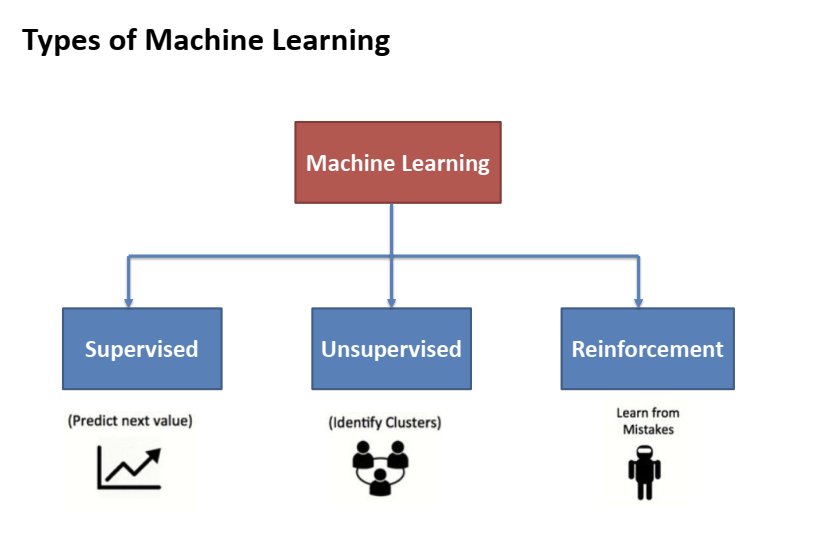

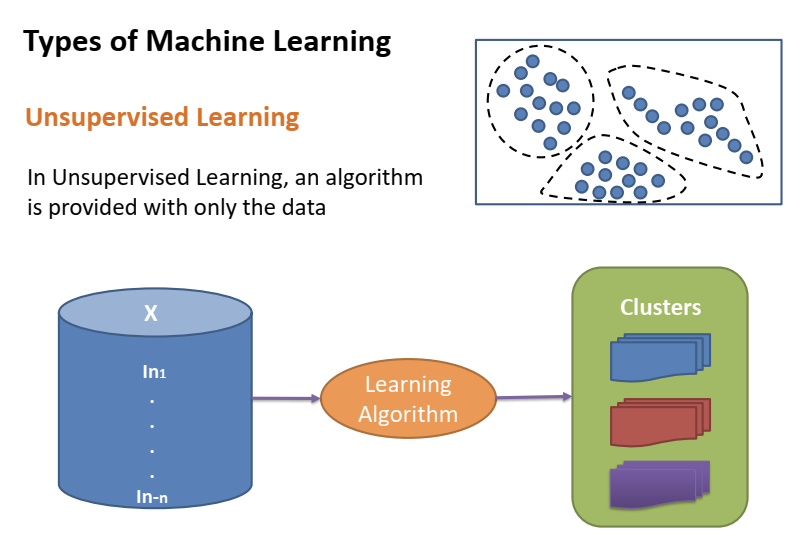

# Clustering 

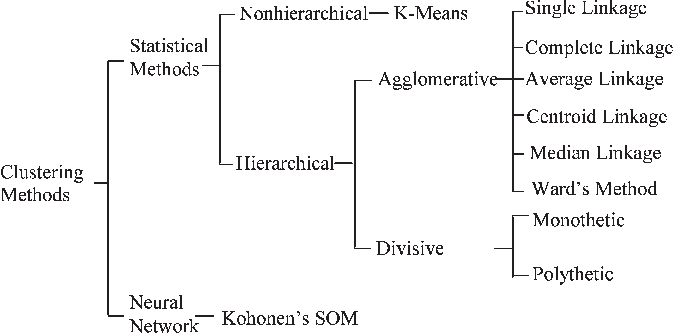

**Clustering (or cluster analysis)** is a technique that allows us to find groups of similar objects, objects that are more related to each other than to objects in other groups. 

Examples of business-oriented applications of clustering:  
- grouping of documents, music, and movies by different topics 
- finding customers that share similar interests based on common purchase behaviors 

# K-means

is one of the most popular clustering algorithms, which is widely used in academia as well as in industry. We will 
cover:

- The basic concepts of k-means clustering
- The mathematics behind the k-means algorithm
- How to implement the algorithm on a sample dataset using scikit-learn
- How to visualize clusters
- How to choose the optimal k using the elbow method

## Basic concepts of k-means clustering

- The k-means algorithm belongs to the category of **prototype-based clustering**.
- centroid (average) of similar points with continuous features
- medoid (the most representative or most frequently occurring point) in the case of categorical features.
- clusters
- K-parameter

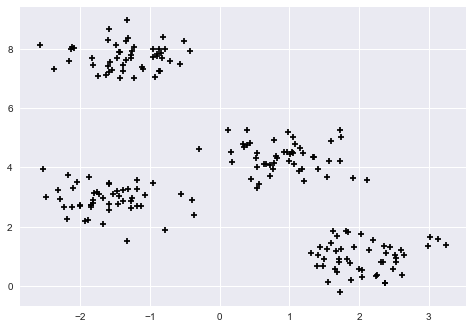

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# setting figure's style
plt.style.use('seaborn')

# create dataset
X, y = make_blobs(n_samples = 200, n_features = 2, centers = 4, cluster_std = 0.5, shuffle = True, random_state = 0)

# plot
plt.scatter( X[:, 0], X[:, 1], c = 'black', marker = '+', s = 40)
plt.show()

## k-means algorithm steps:  https://www.naftaliharris.com/blog/visualizing-k-means-clustering/

1- Randomly select centroids (center of cluster) for each cluster.

2- Calculate the distance of all data points to the centroids.

3- Assign data points to the closest cluster.

4- Find the new centroids of each cluster by taking the mean of all data points in the cluster.

4- Repeat steps 2,3 and 4 until all points converge and cluster centers stop moving.

## how do we measure similarity between objects ?

https://www.saedsayad.com/clustering_kmeans.htm

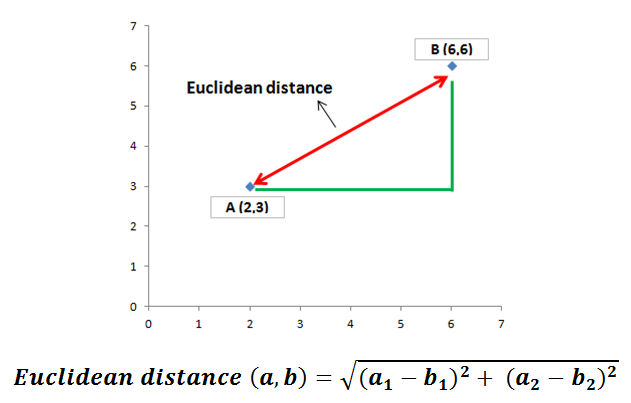

**Note:** Euclidean distance in two dimensions remind us the famous **pythagorean theorem**.

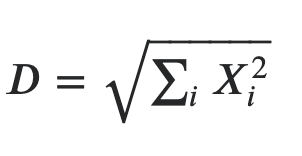

## Scikit-learn Library

Scikit-learn is a free machine learning library for Python. It features various algorithms like SVM, DT, and KNN, and it also supports Python numerical and scientific libraries like NumPy and SciPy.

- useful link: https://scikit-learn.org/stable/

### Installing Scikit-learn (If already installed, skip this cell)

In case, you try to import Scikit-learn directly and it cannot be imported, it means that you have to install it first. In such a case, use the following cell.

In [ ]:
import subprocess
import sys

# If a package (library) is not available, call this function with the name of the missing library
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    
install("sklearn")

## K-means clustering using scikit-learn

In [2]:
from sklearn.cluster import KMeans

"""
n_clusters: the number of desired clusters

n_init: run the k-means clustering algorithms 10 times independently with different 
        random centroids to choose the final model as the one with the lowest SSE
        
max_iter: maximum number of iterations for each single run

tol: tolerance with regard to the changes in the within-cluster SSE to declare convergence

"""

km = KMeans(n_clusters = 4, init = 'random', n_init = 10, max_iter = 300, tol = 1e-04, random_state = 0)
y_km = km.fit_predict(X)


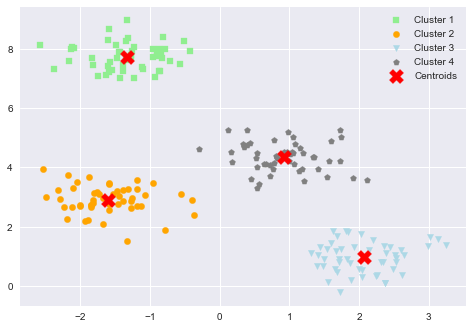

In [3]:
# plot the 4 clusters
plt.scatter(X[y_km == 0, 0], X[y_km == 0, 1], s = 40, c = 'lightgreen', marker = 's',label ='Cluster 1')

plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], s = 40, c = 'orange', marker = 'o', label = 'Cluster 2')

plt.scatter(X[y_km == 2, 0], X[y_km == 2, 1], s = 40, c = 'lightblue', marker = 'v', label = 'Cluster 3')

plt.scatter(X[y_km == 3, 0], X[y_km == 3, 1], s = 40, c = 'grey', marker = 'p', label = 'Cluster 4')

# plot the centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s = 200, marker ='X', c ='red', label = 'Centroids')

plt.legend(scatterpoints = 1)
plt.show()

## The Elbow Method

The elbow method is a useful graphical tool to estimate the optimal number of clusters k for a given task

**Theorem**: if k increases, the within-cluster SSE (“distortion”) will decrease. (samples will be closer to the centroids they are assigned to)

**Optimal value**: identify the value of k where the distortion begins to decrease most rapidly

C:\Users\Adolf\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


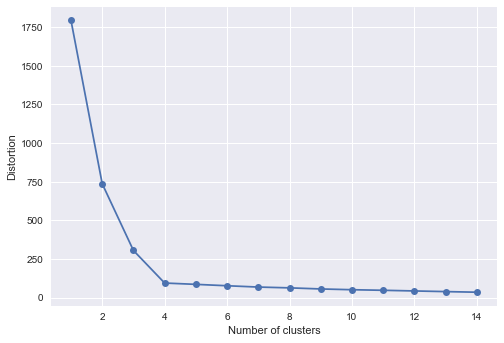

In [4]:
# calculate distortion for a range of number of cluster
distortions = []
for i in range(1, 15):
    km = KMeans(n_clusters = i, init = 'random', n_init = 10, max_iter = 300, tol = 1e-04, random_state = 0)
    km.fit(X)
    distortions.append(km.inertia_)

# plot
plt.plot(range(1, 15), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

As we can see in the resulting plot, the elbow is located at k = 4, which is evidence that k = 4 is indeed a good choice for this dataset.

# DBScan

https://www.coursera.org/lecture/machine-learning-with-python/dbscan-B8ctK

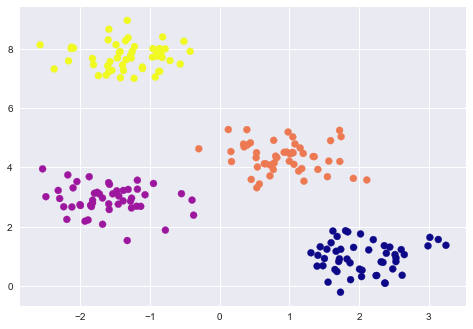

In [5]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# cluster the data into five clusters
dbscan = DBSCAN(eps = 0.35, min_samples = 3)

y_dbscan = dbscan.fit_predict(X_scaled)


plt.scatter(X[:, 0], X[:, 1], c = y_dbscan, cmap = "plasma")
plt.show()

**Note**: As we can see the dbscan could not find the 4 classes. We may need to adjust the parameters or use an even more sophisticated algorithm.

# Hierarchical Clustering

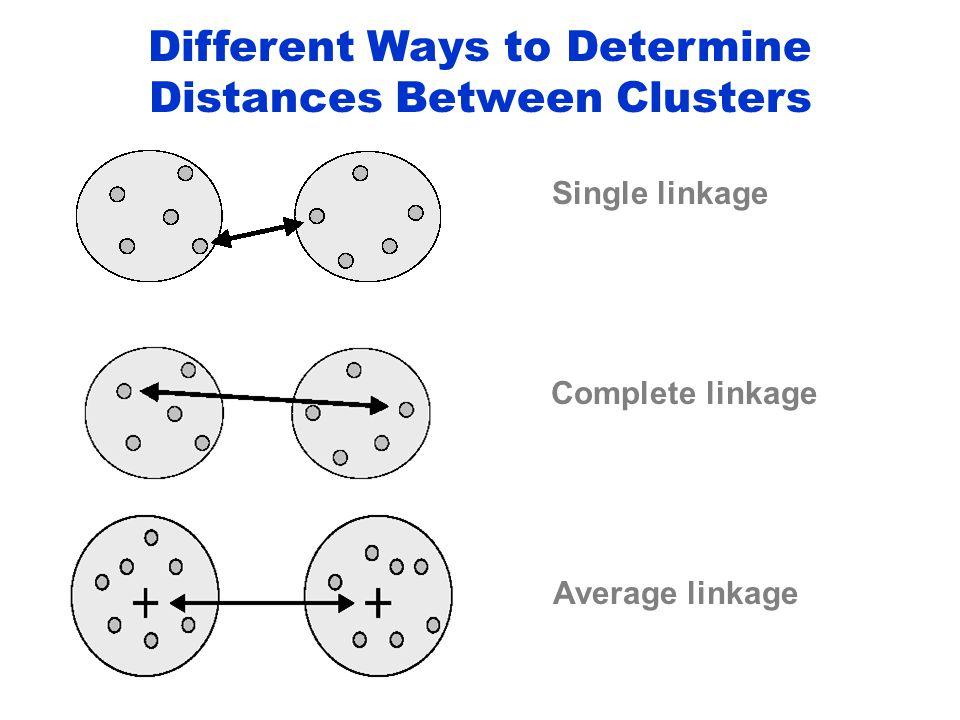

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# importing the Mall_Customers dataset

df = pd.read_csv('Mall_Customers.csv')

X = df.iloc[:, [3,4]].values

## Using Single linkage

Single-linkage (nearest neighbor) is the shortest distance between a pair of observations in two clusters. It can sometimes produce clusters where observations in different clusters are closer together than to observations within their own clusters. These clusters can appear spread-out.

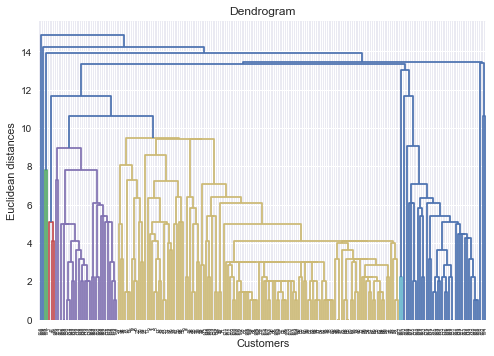

In [7]:
# using the dendrogram to find the optimal numbers of clusters. 
import scipy.cluster.hierarchy as sch

# lets create a dendrogram
dendrogram = sch.dendrogram(sch.linkage(X, method  = "single"))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

## Using Complete linkage 

Complete-linkage (farthest neighbor) is where distance is measured between the farthest pair of observations in two clusters. This method usually produces tighter clusters than single-linkage, but these tight clusters can end up very close together. Along with average-linkage, it is one of the more popular distance metrics.

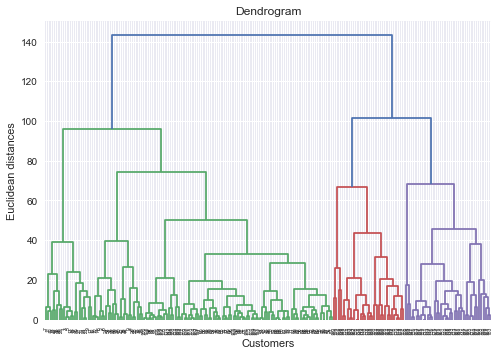

In [8]:
# using the dendrogram to find the optimal numbers of clusters. 
import scipy.cluster.hierarchy as sch

# lets create a dendrogram
dendrogram = sch.dendrogram(sch.linkage(X, method  = "complete"))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

## Using Average linkage

Average-linkage is where the distance between each pair of observations in each cluster are added up and divided by the number of pairs to get an average inter-cluster distance. Average-linkage and complete-linkage are the two most popular distance metrics in hierarchical clustering.

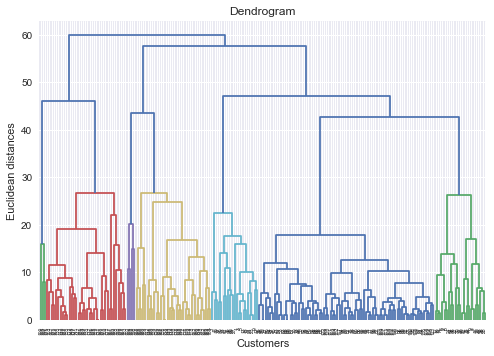

In [9]:
# using the dendrogram to find the optimal numbers of clusters. 
import scipy.cluster.hierarchy as sch

# lets create a dendrogram
dendrogram = sch.dendrogram(sch.linkage(X, method  = "average"))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

## Using Ward linkage

Unlike other linkages and instead of measuring the distance directly, Ward's method analyzes the variance of clusters. Ward’s is said to be the most suitable method for quantitative variables.

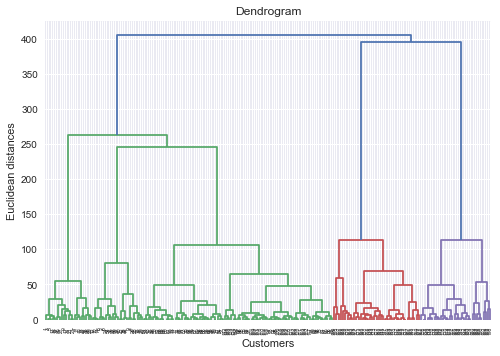

In [10]:
# using the dendrogram to find the optimal numbers of clusters. 
import scipy.cluster.hierarchy as sch

# lets create a dendrogram
dendrogram = sch.dendrogram(sch.linkage(X, method  = "ward"))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

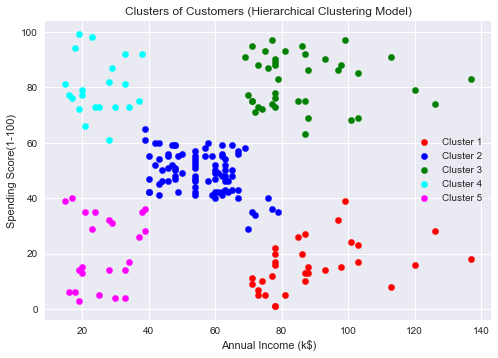

In [11]:
from sklearn.cluster import AgglomerativeClustering 

hc = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage ='ward')
y_hc = hc.fit_predict(X)

plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 40, c='red', label ='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 40, c='blue', label ='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 40, c='green', label ='Cluster 3')
plt.scatter(X[y_hc == 3, 0], X[y_hc == 3, 1], s = 40, c='cyan', label ='Cluster 4')
plt.scatter(X[y_hc == 4, 0], X[y_hc == 4, 1], s = 40, c='magenta', label ='Cluster 5')

plt.title('Clusters of Customers (Hierarchical Clustering Model)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.legend()
plt.show()